In [2]:
# https://zh-v2.d2l.ai/chapter_computer-vision/semantic-segmentation-and-dataset.html


### 语义分割
**仅考虑像素的类别，不分隔同一类的不同实体**

In [3]:
# 早期思路：基于先验，按照颜色进行分割（先验知识不完全准确）
# 现在思路：基于卷积神经网络

%matplotlib inline
import os
import torch
import torchvision
from d2l import torch as d2l # 安装d2l https://blog.csdn.net/wzk4869/article/details/127795541?ops_request_misc=%257B%2522request%255Fid%2522%253A%2522169198550416800226589991%2522%252C%2522scm%2522%253A%252220140713.130102334..%2522%257D&request_id=169198550416800226589991&biz_id=0&utm_medium=distribute.pc_search_result.none-task-blog-2~all~top_click~default-2-127795541-null-null.142^v92^insert_down1&utm_term=d2l&spm=1018.2226.3001.4187

#@save
d2l.DATA_HUB['voc2012'] = (d2l.DATA_URL + 'VOCtrainval_11-May-2012.tar',
                           '4e443f8a2eca6b1dac8a6c57641b67dd40621a49')
''' 
VOC（Visual Object Classes）是一个常用的计算机视觉数据集，用于目标检测、图像分割和图像分类等任务。
VOC数据集通常指的是PASCAL VOC数据集，它是由英国牛津大学的计算机视觉研究组（Visual Geometry Group）创建的。
'''
voc_dir = d2l.download_extract('voc2012', 'VOCdevkit/VOC2012') # d2l.download_extract 函数来下载和提取 VOC2012 数据集，并将其保存在 voc_dir 变量中。


In [4]:


#@save
def read_voc_images(voc_dir, is_train=True):
    """读取所有VOC图像并标注"""
    txt_fname = os.path.join(voc_dir, 'ImageSets', 'Segmentation',
                             'train.txt' if is_train else 'val.txt')
                            # '''
                            # 首先调用 os.path.join 函数来连接以下路径字符串：
                            #  voc_dir: VOC数据集的根目录路径
                            #  ImageSets: VOC数据集中存放图像集合的文件夹。
                            #  Segmentation: 包含语义分割的相关信息的文件夹。
                            #  train.txt 或 val.txt: 根据 is_train 变量来判断是训练集还是验证集。
                            # '''
    mode = torchvision.io.image.ImageReadMode.RGB
    with open(txt_fname, 'r') as f:
        images = f.read().split()
    features, labels = [], []
    for i, fname in enumerate(images):
        # 在 Python 中，enumerate 是一个内置函数，它用于在迭代过程中同时获得元素的索引和值。
        features.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'JPEGImages', f'{fname}.jpg')))
        # JPEGImages 原始图片
        labels.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'SegmentationClass' ,f'{fname}.png'), mode))
        # png 没有压缩
    return features, labels

train_features, train_labels = read_voc_images(voc_dir, True)


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

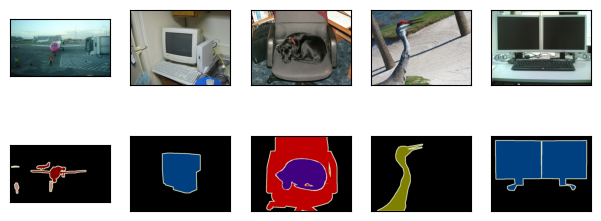

In [5]:
n = 5
# 代码将训练集的前 n 张图像特征与标签进行连接，并将结果保存在名为 imgs 的变量中。这里假设 train_features 和 train_labels 分别是训练集的特征和标签数据。
imgs = train_features[0:n] + train_labels[0:n]
imgs = [img.permute(1,2,0) for img in imgs]
d2l.show_images(imgs, 2, n)
# 绘制前5个输入图像及其标签，在标签图像中，白色和黑色分别表示边框和背景，而其他颜色则对应不同的类别，结果如下图所示

In [6]:
#@save
VOC_COLORMAP = [[0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0],
                [0, 0, 128], [128, 0, 128], [0, 128, 128], [128, 128, 128],
                [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
                [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128],
                [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
                [0, 64, 128]]

# 这段代码定义了 VOC_COLORMAP 和 VOC_CLASSES 两个变量，用于表示 PASCAL VOC 数据集的颜色映射和对象类别。

#@save
VOC_CLASSES = ['background', 'aeroplane', 'bicycle', 'bird', 'boat',
               'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
               'diningtable', 'dog', 'horse', 'motorbike', 'person',
               'potted plant', 'sheep', 'sofa', 'train', 'tv/monitor']

In [7]:
#@save
def voc_colormap2label():
    """构建从RGB到VOC类别索引的映射"""
    colormap2label = torch.zeros(256 ** 3, dtype=torch.long)
    for i, colormap in enumerate(VOC_COLORMAP):
        colormap2label[
            (colormap[0] * 256 + colormap[1]) * 256 + colormap[2]] = i
    return colormap2label

#@save
def voc_label_indices(colormap, colormap2label):
    """将VOC标签中的RGB值映射到它们的类别索引"""
    colormap = colormap.permute(1, 2, 0).numpy().astype('int32')
    idx = ((colormap[:, :, 0] * 256 + colormap[:, :, 1]) * 256
           + colormap[:, :, 2])
    return colormap2label[idx]

In [8]:
y = voc_label_indices(train_labels[0], voc_colormap2label())
y[105:115, 130:140], VOC_CLASSES[1]

(tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
         [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 0, 0, 1, 1]]),
 'aeroplane')

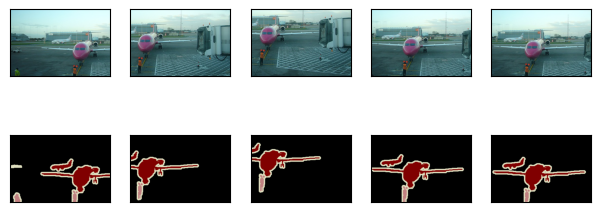

In [9]:

""" 
函数接受四个参数：

feature：特征图像；
label：标签图像；
height：裁剪后的高度；
width：裁剪后的宽度。
"""
#@save
def voc_rand_crop(feature, label, height, width):
    """随机裁剪特征和标签图像"""
    rect = torchvision.transforms.RandomCrop.get_params(
        feature, (height, width))
    feature = torchvision.transforms.functional.crop(feature, *rect)
    label = torchvision.transforms.functional.crop(label, *rect)
    return feature, label

imgs = []
for _ in range(n):
    imgs += voc_rand_crop(train_features[0], train_labels[0], 200, 300)

imgs = [img.permute(1, 2, 0) for img in imgs]
d2l.show_images(imgs[::2] + imgs[1::2], 2, n);

In [10]:
#@save
class VOCSegDataset(torch.utils.data.Dataset):
    """一个用于加载VOC数据集的自定义数据集"""
# """ 
# __init__(self, is_train, crop_size, voc_dir)：初始化函数，接收是否为训练集、裁剪尺寸和数据集的文件路径作为输入参数，并读取VOC数据集。
# normalize_image(self, img)：对图像进行归一化处理的函数。
# filter(self, imgs)：根据裁剪尺寸过滤图像的函数。
# __getitem__(self, idx)：获取指定索引位置的数据样本和标签的函数。
# __len__(self)：获取数据集大小的函数。
# """
    def __init__(self, is_train, crop_size, voc_dir):
        self.transform = torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.crop_size = crop_size
        features, labels = read_voc_images(voc_dir, is_train=is_train)
        self.features = [self.normalize_image(feature)
                         for feature in self.filter(features)]
        self.labels = self.filter(labels)
        self.colormap2label = voc_colormap2label()
        print('read ' + str(len(self.features)) + ' examples')

    def normalize_image(self, img):
        return self.transform(img.float() / 255)

    def filter(self, imgs):
        return [img for img in imgs if (
            img.shape[1] >= self.crop_size[0] and
            img.shape[2] >= self.crop_size[1])]

    def __getitem__(self, idx):
        feature, label = voc_rand_crop(self.features[idx], self.labels[idx],
                                       *self.crop_size)
        return (feature, voc_label_indices(label, self.colormap2label))

    def __len__(self):
        return len(self.features)
    
# https://zh-v2.d2l.ai/chapter_computer-vision/semantic-segmentation-and-dataset.html

In [11]:
crop_size = (320, 480)
voc_train = VOCSegDataset(True, crop_size, voc_dir)
voc_test = VOCSegDataset(False, crop_size, voc_dir)

read 1114 examples
read 1078 examples


In [12]:
batch_size = 64
train_iter = gluon.data.DataLoader(voc_train, batch_size, shuffle=True,
                                   last_batch='discard',
                                   num_workers=d2l.get_dataloader_workers())
for X, Y in train_iter:
    print(X.shape)
    print(Y.shape)
    break

# https://blog.csdn.net/2301_77189428/article/details/129912726?ops_request_misc=&request_id=&biz_id=102&utm_term=gluon%20%E5%BA%93&utm_medium=distribute.pc_search_result.none-task-blog-2~all~sobaiduweb~default-7-129912726.142^v92^insert_down1&spm=1018.2226.3001.4187


NameError: name 'gluon' is not defined